# 01 — Аудит полного официального датасета

## tl;dr
Проверены десять CSV и три вспомогательных источника: 4 434 train labels, 353 ранее просмотренных test labels, 151 validate points. Из текущих 473 audit-точек 382 уже встречались в прошлых audit artifacts: это повторная локальная оценка с ограниченной независимостью, не unseen. Validate proxy из test schedule находится в карантине: 151/151 ключей совпадают, целевое значение не реконструируется.


## Context & Methods
Grain: одна строка labels/points — одна точка прогноза; traffic — пакет; schedule — остановка рейса. Источники: data/README.md и data/docs/Emulator-and-Telematic-Packets-Specification.md. Время датасета сохраняется без смены timezone.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))
from transport_ml.audit import audit, render_report
result = audit(root / 'data')
print(render_report(result))


# Полный аудит официальных данных

Десять официальных CSV, README, спецификация пакетов и архив эмулятора; реконструируемый validate proxy изолирован.

## Источники и grain

| Файл | Строки | Дубли ключа | Точные дубли |
|---|---:|---:|---:|
| train/traffic.csv | 287849 | 0 | 0 |
| train/schedule.csv | 16674 | 0 | 0 |
| labels/labels_train.csv | 4434 | 0 | 0 |
| test/traffic.csv | 105945 | 0 | 0 |
| test/schedule.csv | 5558 | 0 | 0 |
| labels/labels_test.csv | 353 | 0 | 0 |
| validate/traffic.csv | 105945 | 0 | 0 |
| validate/schedule_plan.csv | 5558 | 0 | 0 |
| validate/points.csv | 151 | 0 | 0 |
| sample_submission.csv | 151 | 0 | 0 |

## Связность point с контекстом

| Раздел | Точек | Машина в traffic | Остановка в schedule | Плановое время совпало |
|---|---:|---:|---:|---:|
| train | 4434 | 4434 | 4434 | 4434 |
| test | 353 | 353 | 353 | 353 |
| validate | 151 | 151 | 151 | 151 |

## Доступность и leakage

- train: дубли vehicle/event 8473; отрицательный receive lag 10168; p99 la

## Data
Таблица содержит полный row count, grain и дубли по источникам. Полные null counts, диапазоны дат и SHA-256 лежат в task-local data_audit.json.


In [2]:
profile = pd.DataFrame([{'source': name, 'rows': p['rows'], 'duplicate_key_rows': p['duplicate_key_rows'], 'exact_duplicates': p['exact_duplicate_rows']} for name,p in result['profiles'].items()])
display(profile)
display(pd.DataFrame(result['coverage']).T)


,source,rows,duplicate_key_rows,exact_duplicates
0,train/traffic.csv,287849,0,0
1,train/schedule.csv,16674,0,0
2,labels/labels_train.csv,4434,0,0
3,test/traffic.csv,105945,0,0
4,test/schedule.csv,5558,0,0
5,labels/labels_test.csv,353,0,0
6,validate/traffic.csv,105945,0,0
7,validate/schedule_plan.csv,5558,0,0
8,validate/points.csv,151,0,0
9,sample_submission.csv,151,0,0


,points,join_rows,traffic_vehicle_covered,schedule_target_covered,schedule_target_time_equal
train,4434,4434,4434,4434,4434
test,353,353,353,353,353
validate,151,151,151,151,151


## Results
Распределение показано только для выданных train labels; validate labels и реконструируемый proxy не используются.


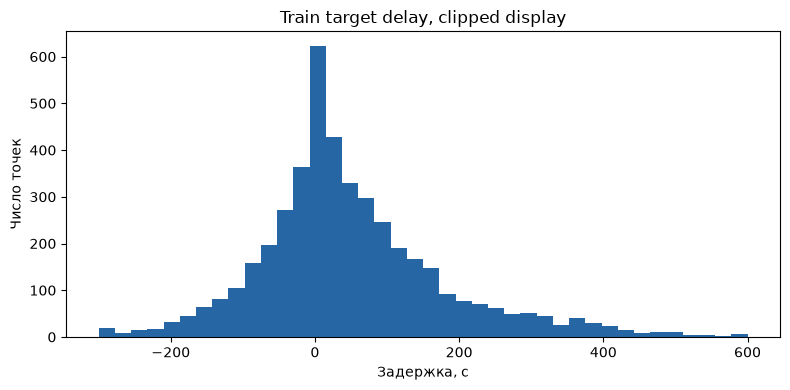

In [3]:
labels = pd.read_csv(root / 'data/labels/labels_train.csv')
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(labels.target_delay_s.clip(-300, 600), bins=40, color='#2766a4')
ax.set(title='Train target delay, clipped display', xlabel='Задержка, с', ylabel='Число точек')
fig.tight_layout()
plt.show()


## Takeaways
Связность каждого раздела, задержки поступления telemetry и реестр предыдущей экспозиции audit напечатаны выше. Для моделирования используется point-in-time фильтр и frozen temporal split; историческую независимость это не восстанавливает.
